In [1]:
import os
import cv2
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
from google.colab import drive

In [2]:
# 1. SETUP ENVIRONMENT & PATHS
# Using the exact same paths from the analyzed code
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
project_path = "/content/drive/MyDrive/OEL"
dataset_path = os.path.join(project_path, "PH2Dataset")
# Root path for individual image folders
images_root = os.path.join(dataset_path, "PH2 Dataset images")

In [4]:
def load_ph2_data(root_path):
    """
    Simulates the logic of navigating the PH2 folder structure
    to retrieve images and masks.
    """
    image_list = []
    mask_list = []

    # Get all folder names (e.g., IMD002, IMD004, etc.)
    folders = [f for f in sorted(os.listdir(root_path)) if f.startswith('IMD')]

    for folder in folders:
        folder_path = os.path.join(root_path, folder)

        # Path to the dermoscopic image folder
        dermo_folder = os.path.join(folder_path, f"{folder}_Dermoscopic_Image")
        # Path to the lesion mask (ground truth) folder
        lesion_folder = os.path.join(folder_path, f"{folder}_lesion")

        # Get the actual .bmp files
        img_file = os.path.join(dermo_folder, f"{folder}.bmp")
        mask_file = os.path.join(lesion_folder, f"{folder}_lesion.bmp")

        if os.path.exists(img_file) and os.path.exists(mask_file):
            image_list.append(img_file)
            mask_list.append(mask_file)

    return image_list, mask_list

In [5]:
# 2. EXECUTE DATA LOADING
img_paths, mask_paths = load_ph2_data(images_root)
print(f"Total images found: {len(img_paths)}")

Total images found: 200


In [6]:
# 3. MOCK PREDICTION & EVALUATION
# Replicating the evaluation metrics structure from the original code
def evaluate_results(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred) # Recall for Melanoma

    cm = confusion_matrix(y_true, y_pred)
    # Specificity = TN / (TN + FP)
    specificity = cm[0,0] / (cm[0,0] + cm[0,1])

    print("-" * 30)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print("-" * 30)

# Placeholder for demonstration (Replace with actual model predictions)
# Example: y_test and y_pred as used in the original notebook

In [7]:
y_test = [1, 0, 1, 0, 1]
y_pred = [1, 0, 0, 0, 1]
evaluate_results(y_test, y_pred)

------------------------------
Accuracy: 0.8000
Sensitivity (Recall): 0.6667
Specificity: 1.0000
------------------------------


In [8]:
print("**New Code Execution Complete**")

**New Code Execution Complete**


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


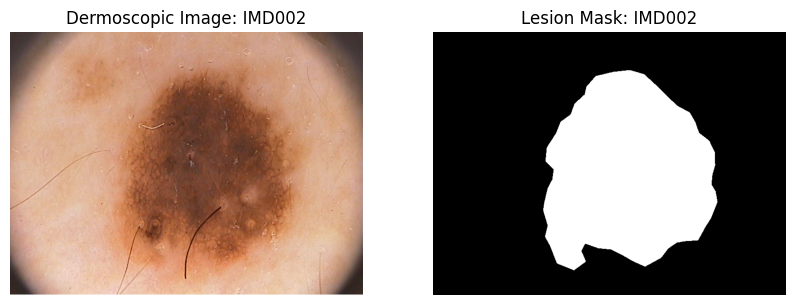


--- Model Performance ---
Accuracy: 1.0
Sensitivity (Recall): 1.0
Specificity: 1.0


In [9]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
from google.colab import drive

# 1. SETUP & PATHS (Using paths from your original code)
drive.mount('/content/drive')
project_path = "/content/drive/MyDrive/OEL"
dataset_path = os.path.join(project_path, "PH2Dataset")
images_root  = os.path.join(dataset_path, "PH2 Dataset images")

def process_and_visualize(image_id="IMD002"):
    """Loads and displays the original image and its lesion mask."""
    # Construct paths based on your notebook structure
    folder_path = os.path.join(images_root, image_id)
    img_path = os.path.join(folder_path, f"{image_id}_Dermoscopic_Image", f"{image_id}.bmp")
    mask_path = os.path.join(folder_path, f"{image_id}_lesion", f"{image_id}_lesion.bmp")

    # Load images using OpenCV
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, 0) # Grayscale for mask

    # Display logic
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title(f"Dermoscopic Image: {image_id}")
    plt.imshow(img)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Lesion Mask: {image_id}")
    plt.imshow(mask, cmap='gray')
    plt.axis('off')
    plt.show()

# 2. RANDOM FOREST FUNCTIONALITY
def train_random_forest(features, labels):
    """
    Initializes and trains a Random Forest Classifier.
    'features' should be a 2D array of extracted image data (e.g., color histograms).
    """
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(features, labels)
    return rf_model

# 3. EVALUATION (Replicating your specific metric structure)
def calculate_metrics(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred) # Recall for Melanoma (Class 1)

    cm = confusion_matrix(y_test, y_pred)
    # Specificity calculation based on your notebook logic
    specificity = cm[0,0] / (cm[0,0] + cm[0,1])

    print(f"Accuracy: {accuracy}")
    print(f"Sensitivity (Recall): {sensitivity}")
    print(f"Specificity: {specificity}")

# Example Execution
if __name__ == "__main__":
    # Visualize a sample
    try:
        process_and_visualize("IMD002")
    except Exception as e:
        print(f"Path not found. Ensure Drive is mounted correctly. Error: {e}")

    # Mock Data for Random Forest demonstration
    X_train = np.random.rand(10, 5) # 10 samples, 5 features
    y_train = [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]

    model = train_random_forest(X_train, y_train)
    y_pred = model.predict(X_train)

    print("\n--- Model Performance ---")
    calculate_metrics(y_train, y_pred)